In [ ]:
# 0: Instala la librería pandas para manejo de datos
!pip install pandas

In [ ]:
# 1: Importa pandas y carga el archivo CSV en un DataFrame llamado "datos"
import pandas as pd
datos = pd.read_csv("train.csv")

In [ ]:
# 2: Muestra las primeras filas del dataset
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 3: Muestra estadísticas descriptivas del dataset (media, desviación, etc.)
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

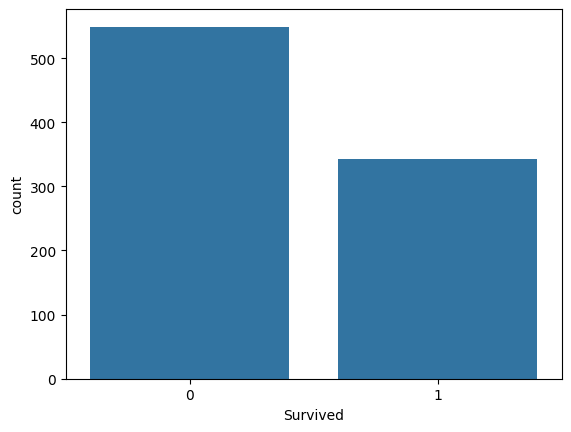

In [ ]:
# 4: Grafica la cantidad de personas que sobrevivieron vs no sobrevivieron
import seaborn as sb
sb.countplot(x="Survived", data=datos)

<Axes: xlabel='Survived', ylabel='count'>

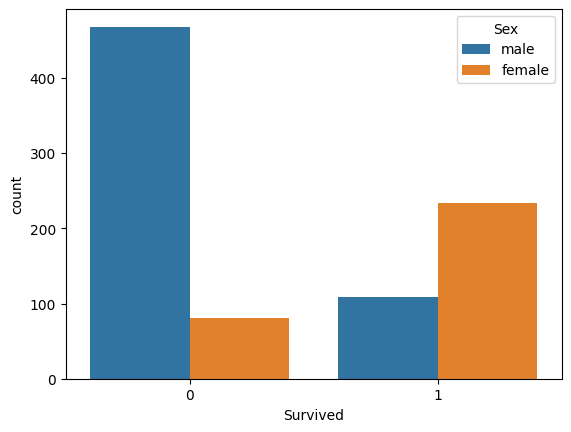

In [ ]:
# 5: Grafica sobrevivientes separados por género
sb.countplot(x="Survived", hue="Sex", data=datos)

In [ ]:
# 6: Cuenta cuántos valores nulos hay en cada columna
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


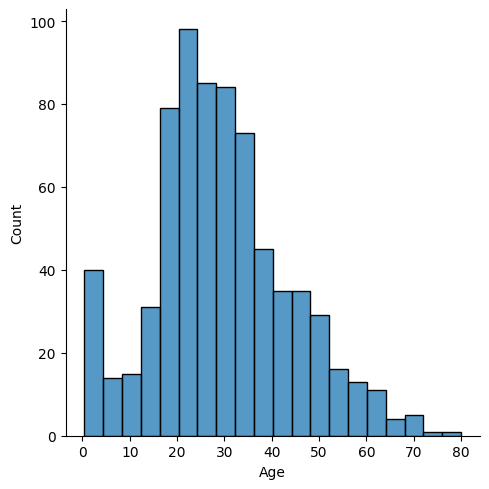

In [ ]:
# 7: Muestra la distribución de la edad
sb.displot(x="Age", data=datos)

In [ ]:
# 8: Muestra la columna de edades
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [ ]:
# 9: Calcula el promedio de la edad
datos["Age"].mean()

np.float64(29.69911764705882)

In [ ]:
# 10: Intenta rellenar valores nulos de la edad con el promedio (pero le falta ejecutar correctamente la función mean())
datos["Age"].fillna(datos["Age"].mean)

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,<bound method Series.mean of 0 22.0\n1 ...
889,26.0


In [ ]:
# 11: Muestra nuevamente la columna Age (para verificar cambios, aunque no se aplicaron correctamente)
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [ ]:
# 12: Verifica nuevamente los valores nulos en el dataset
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# 13: Elimina la columna "Cabin" por tener muchos valores faltantes
datos = datos.drop(["Cabin"], axis=1)

In [ ]:
# 14: Cuenta los valores únicos de la columna "Embarked"
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
# 15: Elimina todas las filas que tengan valores nulos restantes
datos = datos.dropna()

In [ ]:
# 16: Muestra las primeras filas del dataset limpio
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
# 17: Elimina columnas irrelevantes para el modelo (nombre, ID, ticket)
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

In [ ]:
# 18: Convierte la variable categórica "Sex" en variable numérica (dummy)
dummies_Sex = pd.get_dummies(datos["Sex"], drop_first=True).rename(columns={'male': 'Sex_male'})

In [ ]:
# 19: Agrega la nueva columna dummy y elimina la original "Sex"
datos = datos.join(dummies_Sex)
datos = datos.drop(["Sex"], axis=1)

<Axes: xlabel='Survived', ylabel='count'>

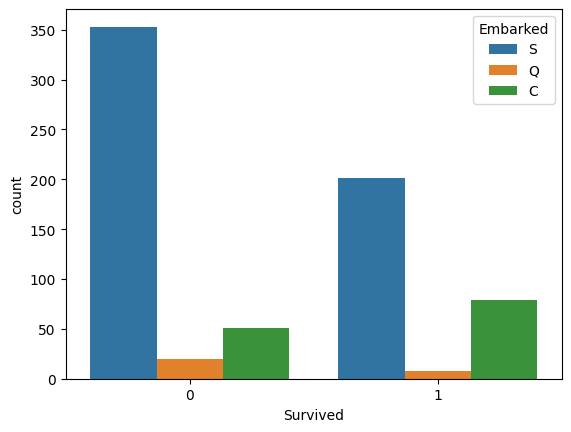

In [ ]:
# 20: Visualiza sobrevivientes según el puerto de embarque
sb.countplot(x="Survived", hue="Embarked", data=datos)

In [ ]:
# 21: Convierte la variable "Embarked" en variables dummy
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [ ]:
# 22: Agrega las columnas dummy y elimina la original "Embarked"
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

<Axes: >

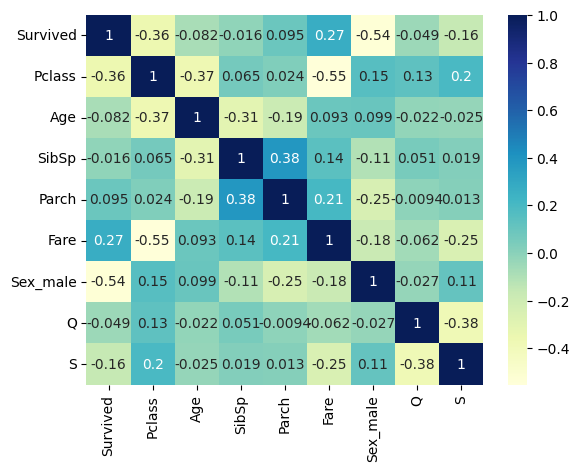

In [ ]:
# 23: Muestra un mapa de calor de correlaciones entre variables
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

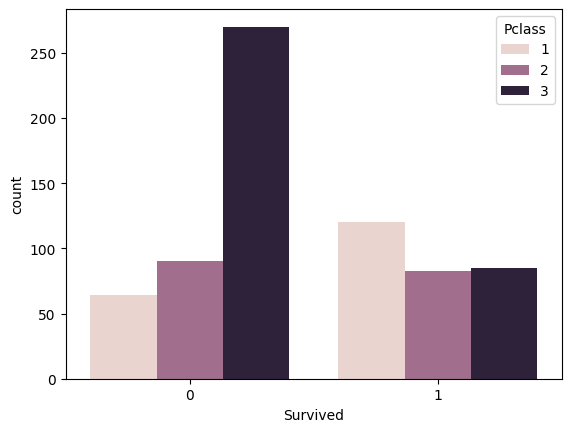

In [ ]:
# 24: Visualiza sobrevivientes según clase social (Pclass)
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [ ]:
# 25: Separa variables independientes (X) y dependiente (y)
X = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

In [ ]:
# 26: Divide los datos en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

X_ent, x_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 27: Crea y entrena un modelo de árbol de decisión
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(x_pru)

In [ ]:
# 29: Importa la función accuracy_score para medir la precisión del modelo
from sklearn.metrics import accuracy_score

accuracy_score(y_pru, predicciones)

0.7482517482517482

IMPORTAMOS LAS METRICAS DE PRECISION

In [ ]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1, 15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(x_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para (i): {exactitud}")
  resultados.append(exactitud)

Resultado para (i): 0.7622377622377622
Resultado para (i): 0.7622377622377622
Resultado para (i): 0.8111888111888111
Resultado para (i): 0.8041958041958042
Resultado para (i): 0.7972027972027972
Resultado para (i): 0.7832167832167832
Resultado para (i): 0.7762237762237763
Resultado para (i): 0.7832167832167832
Resultado para (i): 0.7412587412587412
Resultado para (i): 0.7552447552447552
Resultado para (i): 0.7272727272727273
Resultado para (i): 0.7342657342657343
Resultado para (i): 0.7622377622377622
Resultado para (i): 0.7552447552447552


Importa y muestra un reporte detallado del modelo (precision, recall, f1-score)

<Axes: >

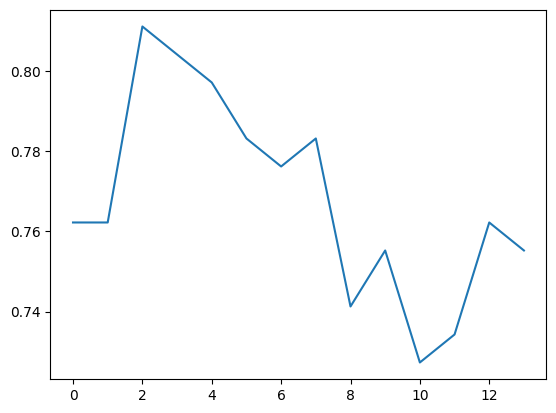

In [ ]:

sb.lineplot(data=resultados)

Genera la matriz de confusión para ver aciertos y errores del modelo

In [ ]:

modelo = DecisionTreeClassifier(max_depth=8)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(x_pru)
exactitud = accuracy_score(y_pru, predicciones)

Convierte la matriz de confusión en una tabla más entendible con etiquetas

In [ ]:

from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84        86
           1       0.82      0.58      0.68        57

    accuracy                           0.78       143
   macro avg       0.80      0.75      0.76       143
weighted avg       0.79      0.78      0.77       143



Muestra las primeras filas de las variables de entrada (X)

In [ ]:

pd.DataFrame(
    confusion_matrix(y_pru, predicciones),
    columns=["Prediccion No", "Prediccion Si"],
    index=["Real No", "Real Si"])

,Prediccion No,Prediccion Si
Real No,79,7
Real Si,24,33


 Muestra el resultado de la predicción (si sobrevive o no)

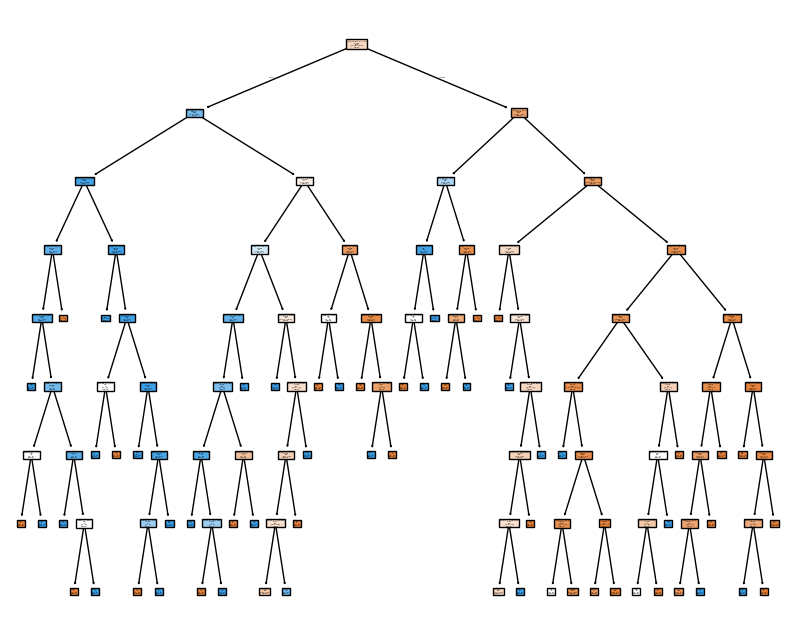

In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(modelo, feature_names=X_ent.columns, class_names=["Murio", "Vivio"], filled=True, label="none")
plt.show()

Calcula la exactitud del modelo

In [ ]:

from sklearn.metrics import accuracy_score

accuracy_score(y_pru, predicciones)

0.7202797202797203

Muestra un reporte de clasificación (precisión, recall, f1-score)

In [ ]:

from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        86
           1       0.63      0.74      0.68        57

    accuracy                           0.72       143
   macro avg       0.71      0.72      0.72       143
weighted avg       0.73      0.72      0.72       143



Genera la matriz de confusión

In [ ]:

from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[61, 25],
       [15, 42]])

Muestra la matriz de confusión en formato de tabla con etiquetas

In [ ]:

pd.DataFrame(
    confusion_matrix(y_pru, predicciones),
    columns=["Prediccion No", "Prediccion Si"],
    index=["Real No", "Real Si"])


,Prediccion No,Prediccion Si
Real No,61,25
Real Si,15,42


Muestra las primeras filas de las variables independientes (X)

In [ ]:

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


Realiza una predicción con datos nuevos (una persona hipotética)

In [ ]:

Nueva_persona = [3, 35, 0, 0, 10, 1, 0, 0]
prediccion = modelo.predict([Nueva_persona])
if prediccion[0] == 1:
  print("Sovreviviste")
else:
  print("No Sovreviviste")

No Sovreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
